# Demo: pixelated LR -> super-resolution output


In [54]:
from pathlib import Path
import sys

import torch
from omegaconf import OmegaConf
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.transforms import functional as TF

# ensure project root on sys.path
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')


Project root: /home/and-petukhov/studies/efml-unet


In [55]:
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
import omegaconf.base as ocbase
import torch.serialization as ts
from src.model import build_model

cfg_dir = PROJECT_ROOT / 'src' / 'configs'

def _manual_load_x8():
    base = OmegaConf.load(cfg_dir / 'baseline_x8_residual.yaml')
    merged = OmegaConf.merge(
        base,
        {'dataloader': OmegaConf.load(cfg_dir / 'dataloader' / 'sr.yaml')},
        {'datasets': OmegaConf.load(cfg_dir / 'datasets' / 'sr_x8.yaml')},
        {'metrics': OmegaConf.load(cfg_dir / 'metrics' / 'sr.yaml')},
        {'model': OmegaConf.load(cfg_dir / 'model' / 'unet.yaml')},
        {'transforms': OmegaConf.load(cfg_dir / 'transforms' / 'sr.yaml')},
        {'writer': OmegaConf.load(cfg_dir / 'writer' / 'console.yaml')},
    )
    return merged

try:
    with initialize_config_dir(config_dir=str(cfg_dir), job_name='demo_x8', version_base=None):
        config = compose(config_name='baseline_x8')
except Exception as e:
    print(f'Hydra compose failed: {e}. Falling back to manual merge.')
    config = _manual_load_x8()

if not hasattr(config, 'model'):
    print('Config missing `model`, using manual merge of defaults.')
    config = _manual_load_x8()

ts.add_safe_globals([ocbase.ContainerMetadata])

ckpt_path = PROJECT_ROOT / 'checkpoints' / 'sr_unet_x8.pt'

device = 'cpu'
model = build_model(config).to(device)
state = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(state['model_state_dict'])
model.eval();
print(f'Loaded checkpoint: {ckpt_path}')
print('Model config:', config.model)


Loaded checkpoint: /home/and-petukhov/studies/efml-unet/checkpoints/sr_unet_x8.pt
Model config: {'name': 'unet', 'in_channels': 3, 'out_channels': 3, 'base_channels': 64, 'bilinear': True, 'residual': True}


In [56]:
# Pick a high-resolution image
hr_path = PROJECT_ROOT / 'data' / 'sr' / 'val_hr' / '0802.png'
hr = Image.open(hr_path).convert('RGB')

# Create LR with the same degradation as training: bicubic down & up, scale x8
scale_down = 8
lr_small = hr.resize((hr.width // scale_down, hr.height // scale_down), Image.BICUBIC)
lr_upscaled = lr_small.resize(hr.size, Image.BICUBIC)

hr, lr_small, lr_upscaled


(<PIL.Image.Image image mode=RGB size=2040x1356>,
 <PIL.Image.Image image mode=RGB size=255x169>,
 <PIL.Image.Image image mode=RGB size=2040x1356>)

In [57]:
# Run the SR model
lr_tensor = TF.to_tensor(lr_upscaled).unsqueeze(0).to(device)
with torch.no_grad():
    sr = model(lr_tensor).clamp(0.0, 1.0)

sr_img = TF.to_pil_image(sr.squeeze(0).cpu())


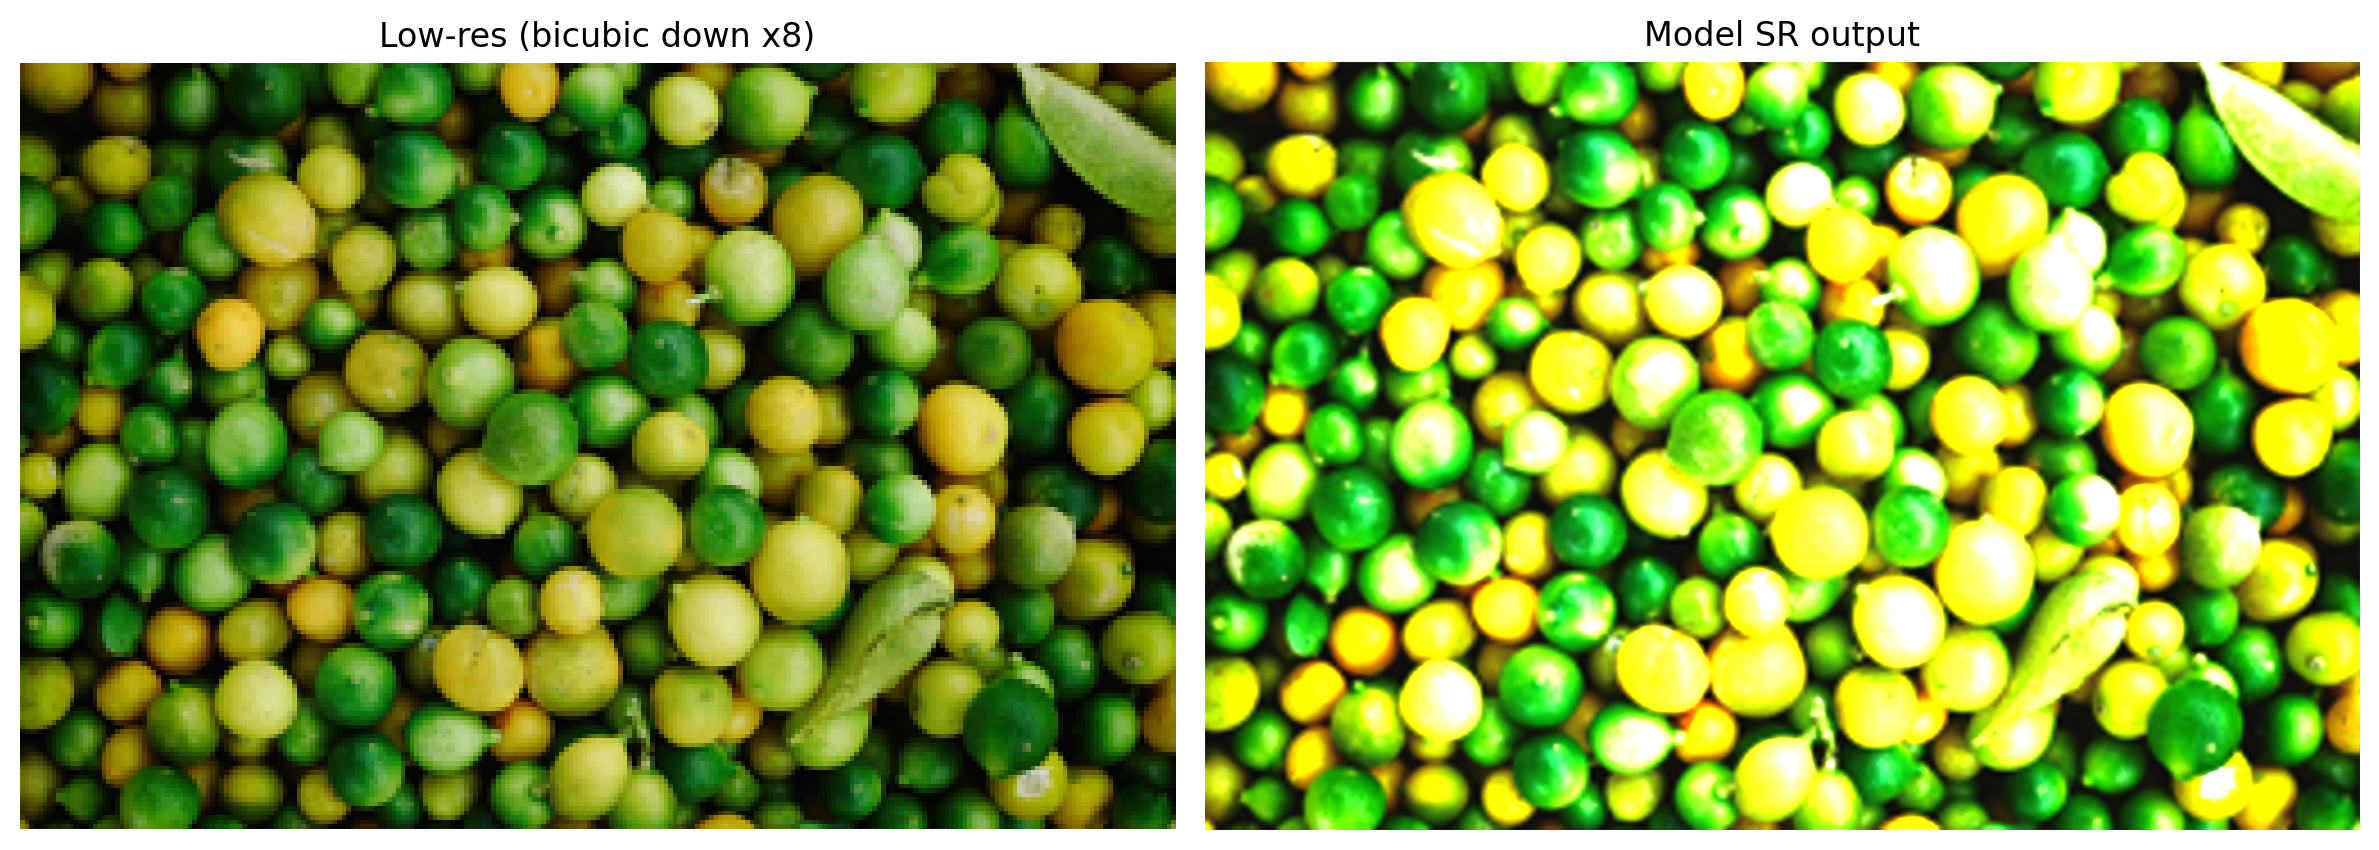

In [58]:
# Visualize: LR small, bicubic up, SR prediction
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
for ax, img, title in zip(
    axes,
    [lr_small, sr_img],
    ['Low-res (bicubic down x8)', 'Model SR output'],
):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()
